# Regresión Lineal — E-Commerce Sales Dataset
## Aprendizaje Automático | Clase 4



---

### Objetivo
Aplicar **regresión lineal** para predecir la variable continua **`Profit`** a partir de las demás variables del dataset de ventas de e-commerce.

### Metodología
1. Preparación y organización de datos
2. Exploración de los datos (EDA)
3. Modelado — Regresión Lineal Simple y Múltiple

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente ✓")

Librerías importadas correctamente ✓


---
## 1. Preparación y organización de datos

In [59]:
# Cargar el dataset
df = pd.read_csv('DataFrames/ecommerce_sales_data.csv')

print(f"Shape: {df.shape}")
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores nulos:")
print(df.isnull().sum())
print()
df.head()

Shape: (3500, 7)

Tipos de datos:
Order Date       object
Product Name     object
Category         object
Region           object
Quantity          int64
Sales             int64
Profit          float64
dtype: object

Valores nulos:
Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64



,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [60]:
print("Resumen estadístico:")
df.describe()

Resumen estadístico:


,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [61]:
# Clasificación de variables
clasificacion = {
    "Variable":        ["Order Date", "Product Name", "Category", "Region", "Quantity", "Sales", "Profit"],
    "Tipo":            ["Fecha",       "Categórica nominal", "Categórica nominal", "Categórica nominal",
                        "Numérica entera", "Numérica entera", "Numérica continua"],
    "Rol":             ["Predictora (extraer Month/Year)", "Predictora (OHE)", "Predictora (OHE)",
                        "Predictora (OHE)", "Predictora", "Predictora", "Variable objetivo"],
    "Tratamiento":     ["pd.to_datetime → Month, Year", "get_dummies(drop_first=True)",
                        "get_dummies(drop_first=True)", "get_dummies(drop_first=True)",
                        "Usar directamente", "Usar directamente", "y target"]
}
pd.DataFrame(clasificacion)

,Variable,Tipo,Rol,Tratamiento
0,Order Date,Fecha,Predictora (extraer Month/Year),"pd.to_datetime → Month, Year"
1,Product Name,Categórica nominal,Predictora (OHE),get_dummies(drop_first=True)
2,Category,Categórica nominal,Predictora (OHE),get_dummies(drop_first=True)
3,Region,Categórica nominal,Predictora (OHE),get_dummies(drop_first=True)
4,Quantity,Numérica entera,Predictora,Usar directamente
5,Sales,Numérica entera,Predictora,Usar directamente
6,Profit,Numérica continua,Variable objetivo,y target


In [62]:
df_prep = df.copy()

# 1. Extraer Month y Year de Order Date
df_prep['Order Date'] = pd.to_datetime(df_prep['Order Date'])
df_prep['Month'] = df_prep['Order Date'].dt.month
df_prep['Year']  = df_prep['Order Date'].dt.year
df_prep.drop(columns=['Order Date'], inplace=True)

# 2. Analizar outliers en Profit con método IQR
Q1  = df_prep['Profit'].quantile(0.25)
Q3  = df_prep['Profit'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers = df_prep[(df_prep['Profit'] < lim_inf) | (df_prep['Profit'] > lim_sup)]

print("=== Detección de Outliers en Profit (método IQR) ===")
print(f"  Q1 = {Q1:.2f}  |  Q3 = {Q3:.2f}  |  IQR = {IQR:.2f}")
print(f"  Límite inferior: {lim_inf:.2f}")
print(f"  Límite superior: {lim_sup:.2f}")
print(f"  Outliers detectados: {len(outliers)} filas ({len(outliers)/len(df_prep)*100:.1f}%)")
print()
print("  Decisión: MANTENER outliers.")
print("  Justificación: representan transacciones reales de alto volumen,")
print("  no errores de captura. Eliminarlos sesgaría el modelo hacia ventas pequeñas.")
print()

# 3. One-Hot Encoding de variables categóricas
df_enc = pd.get_dummies(df_prep,
                        columns=['Category', 'Region', 'Product Name'],
                        drop_first=True, dtype=int)

print(f"Shape final del dataset codificado: {df_enc.shape}")
print(f"Columnas: {list(df_enc.columns)}")

=== Detección de Outliers en Profit (método IQR) ===
  Q1 = 158.69  |  Q3 = 729.12  |  IQR = 570.43
  Límite inferior: -696.95
  Límite superior: 1584.77
  Outliers detectados: 184 filas (5.3%)

  Decisión: MANTENER outliers.
  Justificación: representan transacciones reales de alto volumen,
  no errores de captura. Eliminarlos sesgaría el modelo hacia ventas pequeñas.

Shape final del dataset codificado: (3500, 19)
Columnas: ['Quantity', 'Sales', 'Profit', 'Month', 'Year', 'Category_Electronics', 'Category_Office', 'Region_North', 'Region_South', 'Region_West', 'Product Name_Headphones', 'Product Name_Keyboard', 'Product Name_Laptop', 'Product Name_Monitor', 'Product Name_Mouse', 'Product Name_Printer', 'Product Name_Smartphone', 'Product Name_Smartwatch', 'Product Name_Tablet']


In [63]:
X = df_enc.drop('Profit', axis=1)
y = df_enc['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test:  {y_test.shape}")
print(f"Media Profit train: {y_train.mean():.2f}  |  test: {y_test.mean():.2f}")

X_train: (2800, 18)  |  X_test: (700, 18)
y_train: (2800,)  |  y_test:  (700,)
Media Profit train: 523.44  |  test: 541.46


---
## 2. Exploración de los datos (EDA)

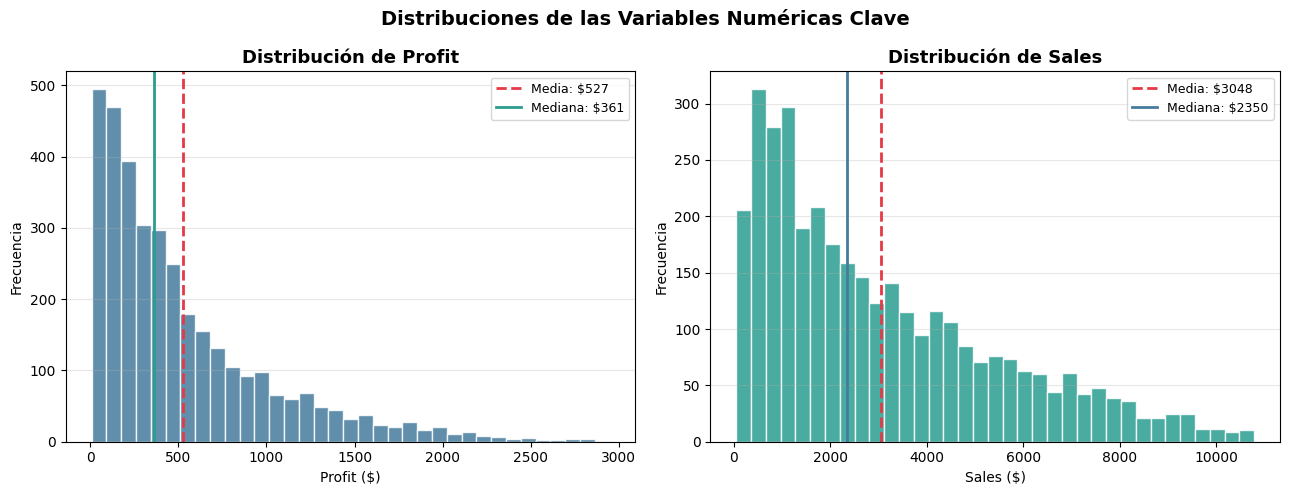

Interpretación:
  Profit: distribución sesgada a la derecha (media $527 > mediana $361).
  Sales:  distribución similar, también sesgada a la derecha.
  Ambas variables tienen 'colas largas', lo que explica los outliers detectados con IQR.


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Histograma Profit ──
axes[0].hist(df['Profit'], bins=35, color='#457b9d', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Profit'].mean(),   color='#e63946', linestyle='--', lw=2,
                label=f"Media: ${df['Profit'].mean():.0f}")
axes[0].axvline(df['Profit'].median(), color='#2a9d8f', linestyle='-',  lw=2,
                label=f"Mediana: ${df['Profit'].median():.0f}")
axes[0].set_title('Distribución de Profit', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Profit ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── Histograma Sales ──
axes[1].hist(df['Sales'], bins=35, color='#2a9d8f', edgecolor='white', alpha=0.85)
axes[1].axvline(df['Sales'].mean(),   color='#e63946', linestyle='--', lw=2,
                label=f"Media: ${df['Sales'].mean():.0f}")
axes[1].axvline(df['Sales'].median(), color='#457b9d', linestyle='-',  lw=2,
                label=f"Mediana: ${df['Sales'].median():.0f}")
axes[1].set_title('Distribución de Sales', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sales ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Distribuciones de las Variables Numéricas Clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretación:")
print(f"  Profit: distribución sesgada a la derecha (media ${df['Profit'].mean():.0f} > mediana ${df['Profit'].median():.0f}).")
print(f"  Sales:  distribución similar, también sesgada a la derecha.")
print("  Ambas variables tienen 'colas largas', lo que explica los outliers detectados con IQR.")

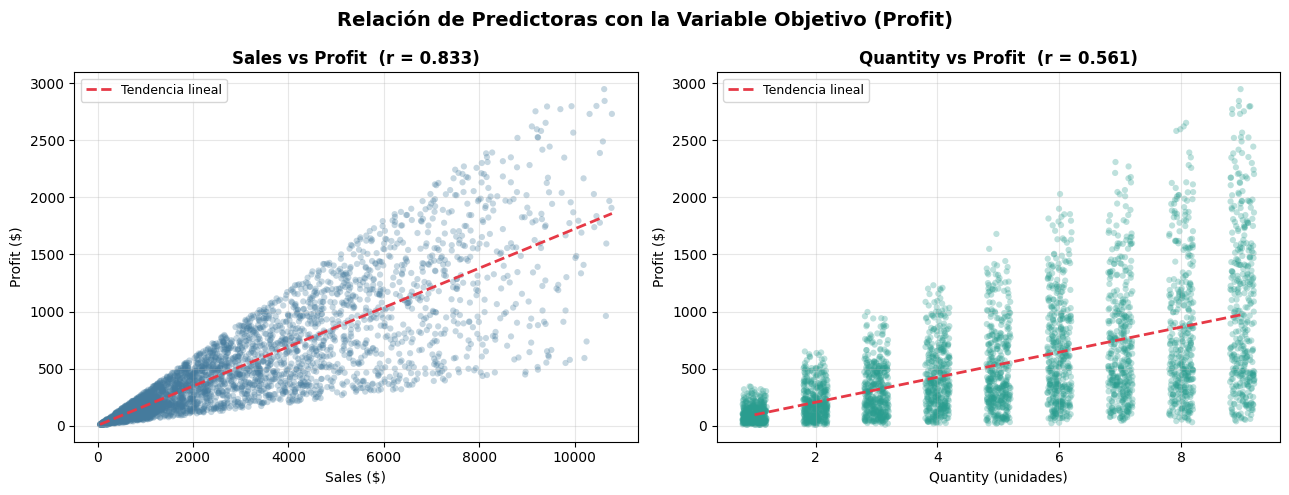

Interpretación:
  Sales → Profit: correlación FUERTE (r=0.833). La nube de puntos muestra
  una tendencia lineal clara: más ventas, más beneficio.
  Quantity → Profit: correlación MODERADA (r=0.561). Más unidades vendidas
  también aumentan el beneficio, pero la dispersión es mayor.


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Sales vs Profit ──
axes[0].scatter(df['Sales'], df['Profit'], color='#457b9d', alpha=0.3, s=20, edgecolors='none')
z = np.polyfit(df['Sales'], df['Profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Sales'].min(), df['Sales'].max(), 200)
axes[0].plot(x_line, p(x_line), '--', color='#e63946', lw=2, label='Tendencia lineal')
r_sales = df['Sales'].corr(df['Profit'])
axes[0].set_title(f'Sales vs Profit  (r = {r_sales:.3f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Profit ($)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── Quantity vs Profit ──
jitter = np.random.RandomState(42).uniform(-0.2, 0.2, size=len(df))
axes[1].scatter(df['Quantity'] + jitter, df['Profit'], color='#2a9d8f', alpha=0.3, s=20, edgecolors='none')
z2 = np.polyfit(df['Quantity'], df['Profit'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['Quantity'].min(), df['Quantity'].max(), 200)
axes[1].plot(x_line2, p2(x_line2), '--', color='#e63946', lw=2, label='Tendencia lineal')
r_qty = df['Quantity'].corr(df['Profit'])
axes[1].set_title(f'Quantity vs Profit  (r = {r_qty:.3f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quantity (unidades)')
axes[1].set_ylabel('Profit ($)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

fig.suptitle('Relación de Predictoras con la Variable Objetivo (Profit)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretación:")
print(f"  Sales → Profit: correlación FUERTE (r={r_sales:.3f}). La nube de puntos muestra")
print("  una tendencia lineal clara: más ventas, más beneficio.")
print(f"  Quantity → Profit: correlación MODERADA (r={r_qty:.3f}). Más unidades vendidas")
print("  también aumentan el beneficio, pero la dispersión es mayor.")

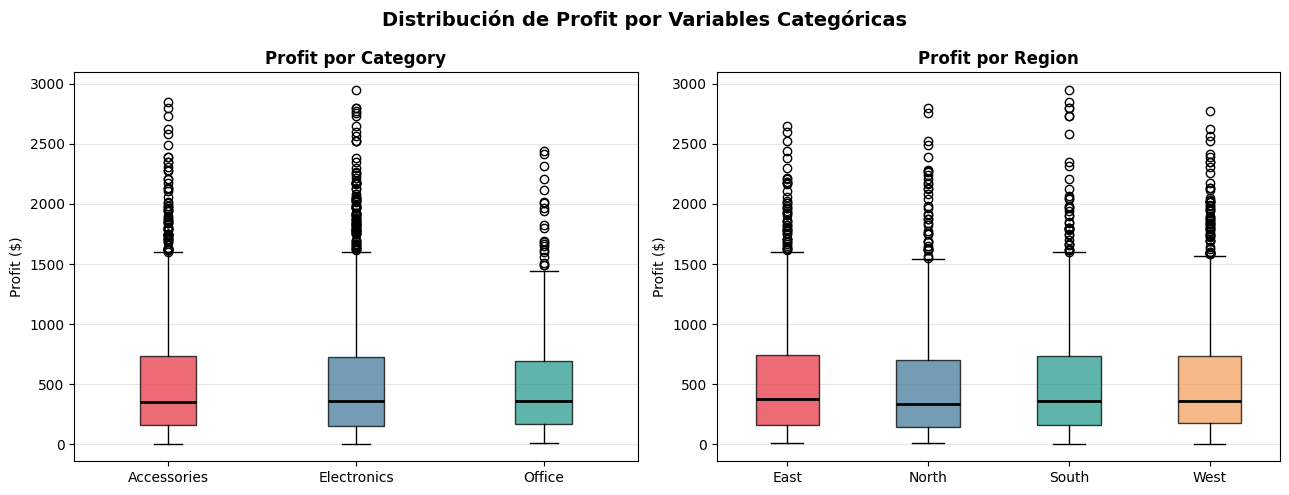

Mediana de Profit por Category:
Category
Accessories    356.43
Electronics    363.40
Office         361.62

Mediana de Profit por Region:
Region
East     378.84
North    332.99
South    357.55
West     365.13

Interpretación:
  Category: Electronics tiene la mediana de Profit más alta, seguida de Office
  y Accessories. Los rangos intercuartílicos son similares entre categorías.
  Region: las cuatro regiones muestran distribuciones de Profit muy similares,
  sugiriendo que la región tiene poco impacto en el beneficio.


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores = ['#e63946', '#457b9d', '#2a9d8f', '#f4a261']

# ── Boxplot por Category ──
cats = sorted(df['Category'].unique())
datos_cat = [df.loc[df['Category'] == c, 'Profit'].values for c in cats]
bp1 = axes[0].boxplot(datos_cat, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp1['boxes'], colores):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_xticklabels(cats, fontsize=10)
axes[0].set_title('Profit por Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Profit ($)')
axes[0].grid(axis='y', alpha=0.3)

# ── Boxplot por Region ──
regions = sorted(df['Region'].unique())
datos_reg = [df.loc[df['Region'] == r, 'Profit'].values for r in regions]
bp2 = axes[1].boxplot(datos_reg, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], colores):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_xticklabels(regions, fontsize=10)
axes[1].set_title('Profit por Region', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Distribución de Profit por Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Mediana por grupo
print("Mediana de Profit por Category:")
print(df.groupby('Category')['Profit'].median().round(2).to_string())
print()
print("Mediana de Profit por Region:")
print(df.groupby('Region')['Profit'].median().round(2).to_string())
print()
print("Interpretación:")
print("  Category: Electronics tiene la mediana de Profit más alta, seguida de Office")
print("  y Accessories. Los rangos intercuartílicos son similares entre categorías.")
print("  Region: las cuatro regiones muestran distribuciones de Profit muy similares,")
print("  sugiriendo que la región tiene poco impacto en el beneficio.")

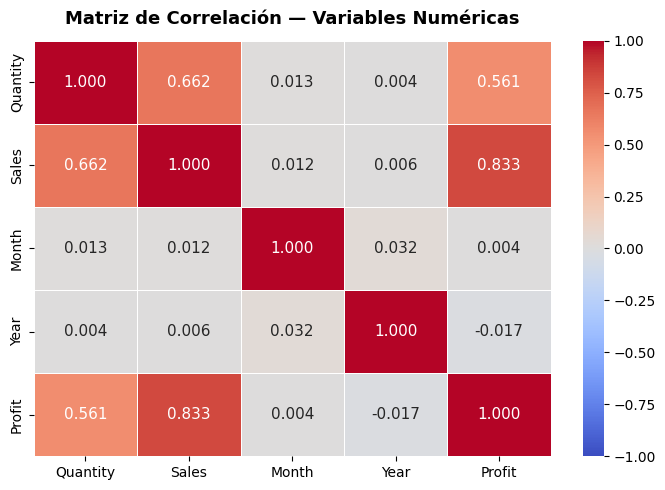

Interpretación:
  Sales  → Profit: r=0.833 (correlación fuerte positiva — predictora principal)
  Quantity → Profit: r=0.561 (correlación moderada positiva)
  Month  → Profit: r≈0.004 (correlación despreciable — no aporta al modelo)
  Year   → Profit: r≈-0.017 (correlación despreciable — no aporta al modelo)


In [67]:
# Añadir Month y Year al df original para la correlación
df_corr = df.copy()
df_corr['Month'] = pd.to_datetime(df_corr['Order Date']).dt.month
df_corr['Year']  = pd.to_datetime(df_corr['Order Date']).dt.year
num_cols = ['Quantity', 'Sales', 'Month', 'Year', 'Profit']
corr_matrix = df_corr[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, ax=ax,
            annot_kws={"size": 11})
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('viz4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretación:")
print("  Sales  → Profit: r=0.833 (correlación fuerte positiva — predictora principal)")
print("  Quantity → Profit: r=0.561 (correlación moderada positiva)")
print("  Month  → Profit: r≈0.004 (correlación despreciable — no aporta al modelo)")
print("  Year   → Profit: r≈-0.017 (correlación despreciable — no aporta al modelo)")

---
## 3. Modelado de datos

  MODELO 1 — Regresión Lineal Simple: Profit ~ Sales
  Intercepto (β₀): -2.6241
  Coeficiente Sales (β₁): 0.174565

  Ecuación: Profit = -2.62 + 0.1746 × Sales

  R²  = 0.6536  (65.4% de la varianza explicada)
  MAE = $199.30
  RMSE= $296.26


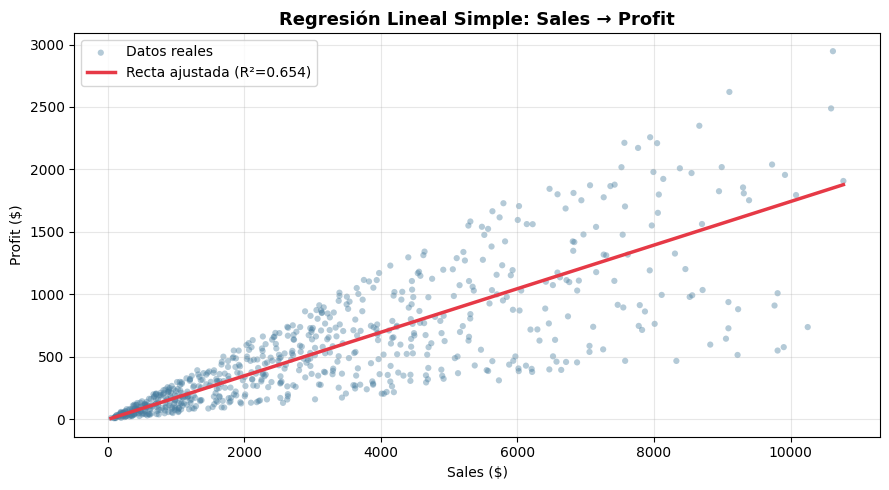

In [68]:
print("=" * 55)
print("  MODELO 1 — Regresión Lineal Simple: Profit ~ Sales")
print("=" * 55)

lr_simple = LinearRegression()
lr_simple.fit(X_train[['Sales']], y_train)
y_pred_s = lr_simple.predict(X_test[['Sales']])

r2_s   = r2_score(y_test, y_pred_s)
mae_s  = mean_absolute_error(y_test, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_s))

print(f"  Intercepto (β₀): {lr_simple.intercept_:.4f}")
print(f"  Coeficiente Sales (β₁): {lr_simple.coef_[0]:.6f}")
print()
print(f"  Ecuación: Profit = {lr_simple.intercept_:.2f} + {lr_simple.coef_[0]:.4f} × Sales")
print()
print(f"  R²  = {r2_s:.4f}  ({r2_s*100:.1f}% de la varianza explicada)")
print(f"  MAE = ${mae_s:.2f}")
print(f"  RMSE= ${rmse_s:.2f}")

# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_test['Sales'], y_test, color='#457b9d', alpha=0.4, s=20,
           label='Datos reales', edgecolors='none')
x_line = np.linspace(X_test['Sales'].min(), X_test['Sales'].max(), 200)
ax.plot(x_line, lr_simple.predict(x_line.reshape(-1,1)), color='#e63946',
        lw=2.5, label=f'Recta ajustada (R²={r2_s:.3f})')
ax.set_title('Regresión Lineal Simple: Sales → Profit', fontsize=13, fontweight='bold')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit ($)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz5_regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()

  MODELO 2 — Regresión Lineal Múltiple
  R²  = 0.6529  (65.3% de la varianza explicada)
  MAE = $200.78
  RMSE= $296.55

Comparativa de modelos:
                          Modelo     R²  MAE ($)  RMSE ($)
         Simple (Sales → Profit) 0.6536   199.30    296.26
Múltiple (todas las predictoras) 0.6529   200.78    296.55

  El modelo múltiple mejora R² en +-0.07 puntos porcentuales.


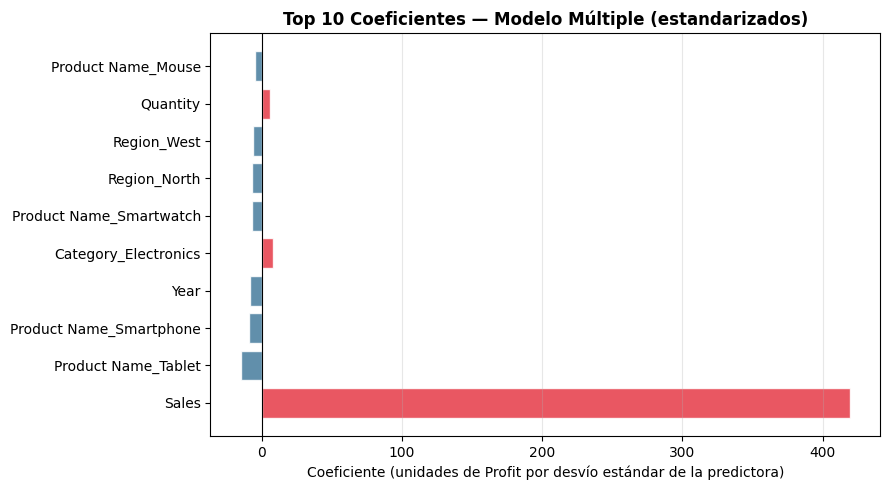


Interpretación de coeficientes (estandarizados):
  El coeficiente más alto corresponde a Sales, confirmando que es la
  predictora dominante. Quantity también aporta significativamente.
  Month y Year tienen coeficientes ≈0, consistente con su correlación nula.


In [69]:
print("=" * 55)
print("  MODELO 2 — Regresión Lineal Múltiple")
print("=" * 55)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr_multi = LinearRegression()
lr_multi.fit(X_train_sc, y_train)
y_pred_m = lr_multi.predict(X_test_sc)

r2_m   = r2_score(y_test, y_pred_m)
mae_m  = mean_absolute_error(y_test, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test, y_pred_m))

print(f"  R²  = {r2_m:.4f}  ({r2_m*100:.1f}% de la varianza explicada)")
print(f"  MAE = ${mae_m:.2f}")
print(f"  RMSE= ${rmse_m:.2f}")
print()

# Tabla comparativa
comp = pd.DataFrame({
    "Modelo":   ["Simple (Sales → Profit)", "Múltiple (todas las predictoras)"],
    "R²":       [round(r2_s, 4), round(r2_m, 4)],
    "MAE ($)":  [round(mae_s, 2), round(mae_m, 2)],
    "RMSE ($)": [round(rmse_s, 2), round(rmse_m, 2)],
})
print("Comparativa de modelos:")
print(comp.to_string(index=False))
print()
mejora = (r2_m - r2_s) * 100
print(f"  El modelo múltiple mejora R² en +{mejora:.2f} puntos porcentuales.")

# Coeficientes top-10
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': lr_multi.coef_
}).reindex(pd.Series(lr_multi.coef_).abs().sort_values(ascending=False).index)
coef_df = coef_df.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colores_bar = ['#e63946' if c > 0 else '#457b9d' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colores_bar, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 10 Coeficientes — Modelo Múltiple (estandarizados)', fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente (unidades de Profit por desvío estándar de la predictora)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('viz6_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("Interpretación de coeficientes (estandarizados):")
print("  El coeficiente más alto corresponde a Sales, confirmando que es la")
print("  predictora dominante. Quantity también aporta significativamente.")
print("  Month y Year tienen coeficientes ≈0, consistente con su correlación nula.")

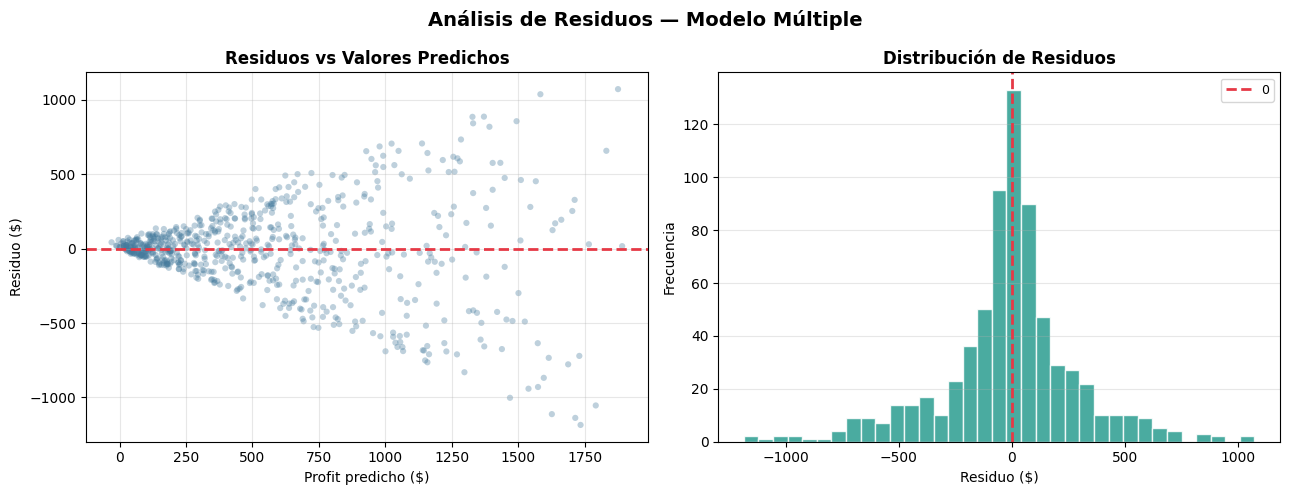

Media de residuos: -12.1949  (esperado: ≈0)
Std  de residuos:  296.30

Interpretación:
  Los residuos se distribuyen aproximadamente en torno a 0 (sin sesgo sistemático).
  La dispersión aumenta para predicciones altas (leve heterocedasticidad),
  lo que sugiere que el modelo sub-predice los Profits muy elevados.
  Para mejorar esto se podría aplicar una transformación logarítmica a Profit.


In [70]:
residuos = y_test.values - y_pred_m

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter residuos vs predichos
axes[0].scatter(y_pred_m, residuos, color='#457b9d', alpha=0.35, s=20, edgecolors='none')
axes[0].axhline(0, color='#e63946', linestyle='--', lw=2)
axes[0].set_title('Residuos vs Valores Predichos', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Profit predicho ($)')
axes[0].set_ylabel('Residuo ($)')
axes[0].grid(alpha=0.3)

# Histograma de residuos
axes[1].hist(residuos, bins=35, color='#2a9d8f', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#e63946', linestyle='--', lw=2, label='0')
axes[1].set_title('Distribución de Residuos', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residuo ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Análisis de Residuos — Modelo Múltiple', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz7_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Media de residuos: {residuos.mean():.4f}  (esperado: ≈0)")
print(f"Std  de residuos:  {residuos.std():.2f}")
print()
print("Interpretación:")
print("  Los residuos se distribuyen aproximadamente en torno a 0 (sin sesgo sistemático).")
print("  La dispersión aumenta para predicciones altas (leve heterocedasticidad),")
print("  lo que sugiere que el modelo sub-predice los Profits muy elevados.")
print("  Para mejorar esto se podría aplicar una transformación logarítmica a Profit.")

In [71]:
print("  RESUMEN COMPARATIVO DE MODELOS")
resumen = pd.DataFrame({
    "Modelo":   ["Lineal Simple (Sales)", "Lineal Multiple (todas)"],
    "R2":       [round(r2_s, 4),  round(r2_m, 4)],
    "MAE ($)":  [round(mae_s, 2), round(mae_m, 2)],
    "RMSE ($)": [round(rmse_s, 2), round(rmse_m, 2)],
})
print(resumen.to_string(index=False))

  RESUMEN COMPARATIVO DE MODELOS
                 Modelo     R2  MAE ($)  RMSE ($)
  Lineal Simple (Sales) 0.6536   199.30    296.26
Lineal Multiple (todas) 0.6529   200.78    296.55


### Conclucion


Lo más interesante que me encontré fue que el modelo múltiple (con todas las variables) no le ganó al simple (solo con Sales). Ambos dieron un R² de ~0.65 y un error promedio de $199, prácticamente idénticos.

Eso me hizo entender que agregar más variables no siempre mejora el modelo en este caso, Sales sola ya explica el 65% del Profit, y las variables categóricas como Region o Category terminaron agregando ruido en lugar de información útil. Month y Año directamente tuvieron correlación casi cero con el objetivo.

El otro hallazgo fue que los residuos mostraron heterocedasticidad leve: el modelo se equivoca más cuando el Profit es alto, lo que sugiere que hay relaciones no lineales que la regresión lineal no logra capturar. Para mejorar eso, el siguiente paso sería aplicar una transformación logarítmica o probar con Random Forest.


En resumen: útil como punto de partida, pero con techo claro.
### Hallazgos principales

1. **Sales es la predictora dominante** (r=0.833): explica ~65% de la varianza de Profit por sí sola.
2. **El modelo múltiple no supera al simple** en este dataset: las variables categóricas (OHE) agregan ruido en lugar de información útil.
3. **Month y Year tienen correlación ≈ 0** con Profit: sus coeficientes son prácticamente cero.
4. **Quantity aporta moderadamente** (r=0.561), pero su contribución ya está parcialmente capturada por Sales.
5. **Los residuos muestran leve heterocedasticidad** para valores altos de Profit.

